In [9]:
import multiprocessing as mp
import os
import pickle
import random
import re
import sys
from timeit import default_timer as timer
import collections

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tmap as tm
from faerun import Faerun
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors
from tqdm import tqdm
from tqdm.auto import trange

sys.path.append("../../src")

from util import *

RDLogger.DisableLog('rdApp.*')

import glob
import os
import pickle
import sys
import warnings
from datetime import datetime

import pandas as pd
import xgboost as xgb
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

RDLogger.DisableLog('rdApp.*')

/root/.pyenv/versions/anaconda3-2024.10-1/envs/tmap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
def compute_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return None

def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t])
    purity = np.sum(matches) / len(matches)
    return purity

# make tmap (only for classification task) 

In [8]:
df = pd.read_csv('../../data/processed/tdc/Tox/4_hERG_Karim_date.tsv', header=0, sep='\t', names=['smiles', 'tox', 'year'])
df = df.sort_values(by='year', ascending=True).reset_index(drop=True)
print(len(df))

6716


In [9]:
df.head()

,smiles,tox,year
0,CCC1(c2ccccc2)C(=O)NC(=O)NC1=O,0,1973.044
1,CC(=O)Oc1ccccc1C(=O)O,0,1973.044
2,CN1CCCC1c1cccnc1,0,1973.101
3,CCN(CC)CCNC(=O)c1ccc(N)cc1,0,1973.121
4,COC(=O)[C@H]1[C@H]2C[C@@H]3c4[nH]c5cc(OC)ccc5c...,1,1973.236


In [10]:
smiles = []
years = []
ecfps = []
toxs = []
tpsa = []
mw = []
logp = []

for i in trange(len(df)):
    smiles.append(df.iloc[i,0])
    years.append(int(df.iloc[i,2]))
    ecfps.append(compute_ecfp(df.iloc[i,0]))
    toxs.append(df.iloc[i,1])
    mol = Chem.MolFromSmiles(df.iloc[i,0])
    tpsa.append(Descriptors.MolWt(mol))
    mw.append(Descriptors.TPSA(mol))
    logp.append(Descriptors.MolLogP(mol))

  0%|          | 0/6716 [00:00<?, ?it/s]

100%|██████████| 6716/6716 [00:17<00:00, 394.89it/s]


In [11]:
c = collections.Counter(toxs)
print(c)

Counter({np.int64(0): 3675, np.int64(1): 3041})


In [12]:
enc = tm.Minhash(128)
lf = tm.LSHForest(128)

d = 2048
n = len(smiles)

data = []
start = timer()
for x in trange(n):
    data.append(tm.VectorUchar(np.array(ecfps[x])))
print(f"Generating the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.batch_add(enc.batch_from_binary_array(data))
print(f"Adding the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.index()
print(f"Indexing took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
knng_from = tm.VectorUint()
knng_to = tm.VectorUint()
knng_weight = tm.VectorFloat()

_ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)
print(f"make knn graph {(timer() - start) * 1000}ms.", flush=True)

100%|██████████| 6716/6716 [00:23<00:00, 284.45it/s]

Generating the data took 23611.813332885504ms.


Adding the data took 8979.027470573783ms.
Indexing took 1096.980893984437ms.
make knn graph 3699.3955206125975ms.


In [13]:
labels = []
for year in years:
    labels.append(year)

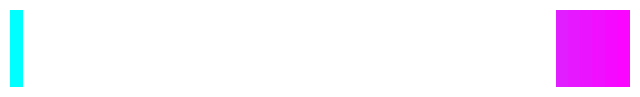

In [14]:
num_colors = min(labels)
total_colors = max(labels) - min(labels) + 1 


base_cmap = plt.get_cmap("cool")
colors = [base_cmap(i / total_colors) for i in range(total_colors)]

black_section = [(0, 0, 0, 0)] * num_colors
new_colors = black_section + colors

MY_CM = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

colors_section = new_colors[num_colors:]  

for i in range(1, len(colors_section)-6):
    colors_section[i] = (0, 0, 0, 0)

new_colors[num_colors:] = colors_section

MY_CM_SELECTED = LinearSegmentedColormap.from_list("my_map_black", colors_section, N=len(colors_section))
MY_CM_3 = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1))
plt.imshow(gradient, aspect="auto", cmap=MY_CM_SELECTED)
plt.axis("off")
plt.show()

In [15]:
custom_cmap = ListedColormap(
    ["#ffffff", "#ff0000"],
    name="custom",
)

custom_cmap_4 = ListedColormap(
    ["#ffffff", "#ff0000", "#00bfff", "#ffb6c1"],
    name="bright_contrast"
)

custom_cmap_6 = ListedColormap(
    ["#ffffff", "#ffff00", "#ffa500", "#ff0000", "#8b0000", "#000000"],
    name="dramatic6"
)

labels_ = list(set(labels))
labels_.sort()
year_label = [[y, str(y)] for y in labels_]

map_original_y = [
    [0, 'Non-Toxic (y=0)'],
    [1, 'Toxic (y=1)']
]

map_tested_y = [
    [0, 'Train (y=0)'],
    [1, 'Train (y=1)'],
    [2, 'Test - Actual Non-Toxic (y=0)'],
    [3, 'Test - Actual Toxic (y=1)']
]

map_predicted_y = [
    [0, 'Train (y=0)'],
    [1, 'Train (y=1)'],
    [2, 'Predicted Non-Toxic'],
    [3, 'Predicted Toxic']
]

map_result_labels = [
    [0, 'Train Data (y=0)'],
    [1, 'Train Data (y=1)'],
    [2, 'Correctly Predicted Non-Toxic (TN)'],
    [3, 'Correctly Predicted Toxic (TP)'],
    [4, 'Incorrectly Predicted Toxic (FP)'],  
    [5, 'Incorrectly Predicted Non-Toxic (FN)'] 
]

In [16]:
X = ecfps
y = toxs

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
result = ["time", r2, mse, mae, sum(y)/len(y), sum(y_train)/len(y_train), sum(y_test)/len(y_test)]

original_y_list = list(y)
train_y_list = list(y_train) 
test_y_list = list(y_pred)  

tested_y_list = []
for pred_val in y_test:
    if pred_val >= 0.5:
        tested_y_list.append(3)
    else:
        tested_y_list.append(2)
tested_y_list = train_y_list + tested_y_list

predicted_y_list = []
for pred_val in y_pred:
    if pred_val >= 0.5:
        predicted_y_list.append(3)
    else:
        predicted_y_list.append(2)
predicted_y_list = train_y_list + predicted_y_list

result_labels = []
for true_val, pred_val in zip(y_test, y_pred):
    pred_val_rounded = round(pred_val) 
    if true_val == pred_val_rounded and true_val == 1:
        result_labels.append(3)
    elif true_val == pred_val_rounded and true_val == 0:
        result_labels.append(2)
    elif pred_val_rounded == 0:
        result_labels.append(5) 
    else:
        result_labels.append(4) 
result_labels = train_y_list + result_labels

In [17]:
smiles_s = [] 
years_s = []  
ecfps_s = [] 
toxs_s = []  

for i in trange(len(df)):
    smiles_s.append(df.iloc[i, 0])
    years_s.append(int(df.iloc[i, 2]))
    ecfps_s.append(compute_ecfp(df.iloc[i, 0])) 
    toxs_s.append(df.iloc[i, 1])  

X_s = ecfps_s
y_s = toxs_s

X_train_s, X_test_s, y_train_s, y_test_s, train_indices_s, test_indices_s = train_test_split(
    X_s, y_s, range(len(X_s)), test_size=0.3, shuffle=True
)

smiles_train_s = [smiles_s[i] for i in train_indices_s]
smiles_test_s = [smiles_s[i] for i in test_indices_s]
years_train_s = [years_s[i] for i in train_indices_s]
years_test_s = [years_s[i] for i in test_indices_s]

le = LabelEncoder()
y_train_encoded_s = le.fit_transform(y_train_s)

model = xgb.XGBClassifier()
model.fit(X_train_s, y_train_encoded_s)

y_pred_s = model.predict(X_test_s)

r2_s = r2_score(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
mae_s = mean_absolute_error(y_test_s, y_pred_s)
result_s = [
    "time",
    r2_s,
    mse_s,
    mae_s,
    sum(y_s) / len(y_s),
    sum(y_train_s) / len(y_train_s),
    sum(y_test_s) / len(y_test_s),
]

n_samples = len(smiles_s)
tested_y_list_ordered = [None] * n_samples
predicted_y_list_ordered = [None] * n_samples
result_labels_ordered = [None] * n_samples

train_y_list_s = y_train_s

for i, idx in enumerate(train_indices_s):
    tested_y_list_ordered[idx] = train_y_list_s[i]
    predicted_y_list_ordered[idx] = train_y_list_s[i]
    result_labels_ordered[idx] = train_y_list_s[i]   

for i, idx in enumerate(test_indices_s):
    tested_y_list_ordered[idx] = 3 if y_test_s[i] >= 0.5 else 2
    predicted_y_list_ordered[idx] = 3 if y_pred_s[i] >= 0.5 else 2

    pred_val_rounded = round(y_pred_s[i])
    if y_test_s[i] == pred_val_rounded and y_test_s[i] == 1:
        result_labels_ordered[idx] = 3
    elif y_test_s[i] == pred_val_rounded and y_test_s[i] == 0:
        result_labels_ordered[idx] = 2
    elif pred_val_rounded == 0: #
        result_labels_ordered[idx] = 5                       
    else:
        result_labels_ordered[idx] = 4

  0%|          | 0/6716 [00:00<?, ?it/s]

100%|██████████| 6716/6716 [00:02<00:00, 2663.09it/s]


In [18]:
y_prob = model.predict_proba(X_test)
auroc = roc_auc_score(y_test, y_prob[:, 1])
y_prob_s = model.predict_proba(X_test_s)
auroc_s = roc_auc_score(y_test_s, y_prob_s[:, 1])
result = ["time", r2, mse, mae, sum(y)/len(y), sum(y_train)/len(y_train), sum(y_test)/len(y_test), auroc]
print(f"auroc: {auroc}")
result_s = ["time", r2_s, mse_s, mae_s, sum(y_s)/len(y_s), sum(y_train_s)/len(y_train_s), sum(y_test_s)/len(y_test_s), auroc_s]
print(f"auroc (shuffle): {auroc_s}")

auroc: 0.9506054952476188
auroc (shuffle): 0.8725922813959356


In [19]:
categorical_maps_list = [
    year_label,              
    year_label,                   
    map_original_y,         
    map_tested_y,           
    map_predicted_y,        
    map_result_labels       
]

In [20]:
x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

faerun = Faerun(clear_color="#111111", view="front", coords=False)

faerun.add_scatter(
    "tdc_12_hERG",
    {"x": x, "y": y, "c": [labels, labels, original_y_list, tested_y_list_ordered, predicted_y_list_ordered, result_labels_ordered], "labels": smiles},
    colormap=[MY_CM, MY_CM_3, custom_cmap, custom_cmap_4, custom_cmap_4, custom_cmap_6],
    shader="smoothCircle",
    series_title=["Year", "Year_2", "Original Y", "Tested Y", "Predicted Y", "Result Type"], 
    categorical=[True, True, True, True, True, True],
    legend_labels=categorical_maps_list,
    point_scale=2.5,
    max_point_size=30,
    has_legend=True,
)
faerun.add_tree(
    "tdc_12_hERG_tree", {"from": s, "to": t}, point_helper="tdc_12_hERG", color="#666666"
)

faerun.plot("tdc_12_hERG", template="smiles")

/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/notebook/experiment/tdc_12_hERG.html

In [15]:
def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t])
    purity = np.sum(matches) / len(matches)
    return purity

labels = np.array(labels) 
lsh_purity_real = lsh_forest_purity(s, t, labels)

num_permutations = 1000
random_purities = []

for _ in trange(num_permutations):
    shuffled_labels = np.random.permutation(labels)
    random_purity = lsh_forest_purity(s, t, shuffled_labels)
    random_purities.append(random_purity)

random_purities = np.array(random_purities)
p_value = np.mean(random_purities >= lsh_purity_real)


print(f"LSH Forest Edge Homophily Ratio (Real): {lsh_purity_real:.4f}")
print(f"Mean Random Homophily Ratio: {random_purities.mean():.4f}")
print(f"p-value: {p_value:.4f}")

100%|██████████| 1000/1000 [00:08<00:00, 118.93it/s]

LSH Forest Edge Homophily Ratio (Real): 0.5270
Mean Random Homophily Ratio: 0.0611
p-value: 0.0000


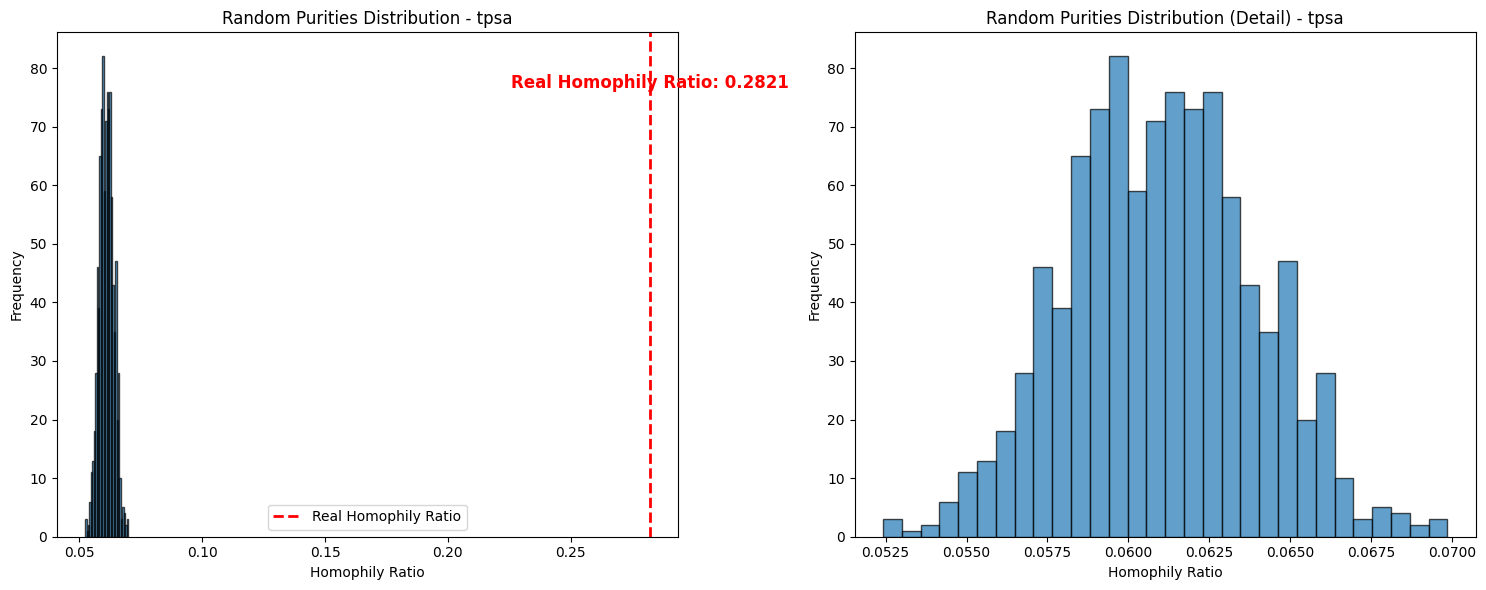

<built-in function id> 0.0 tpsa


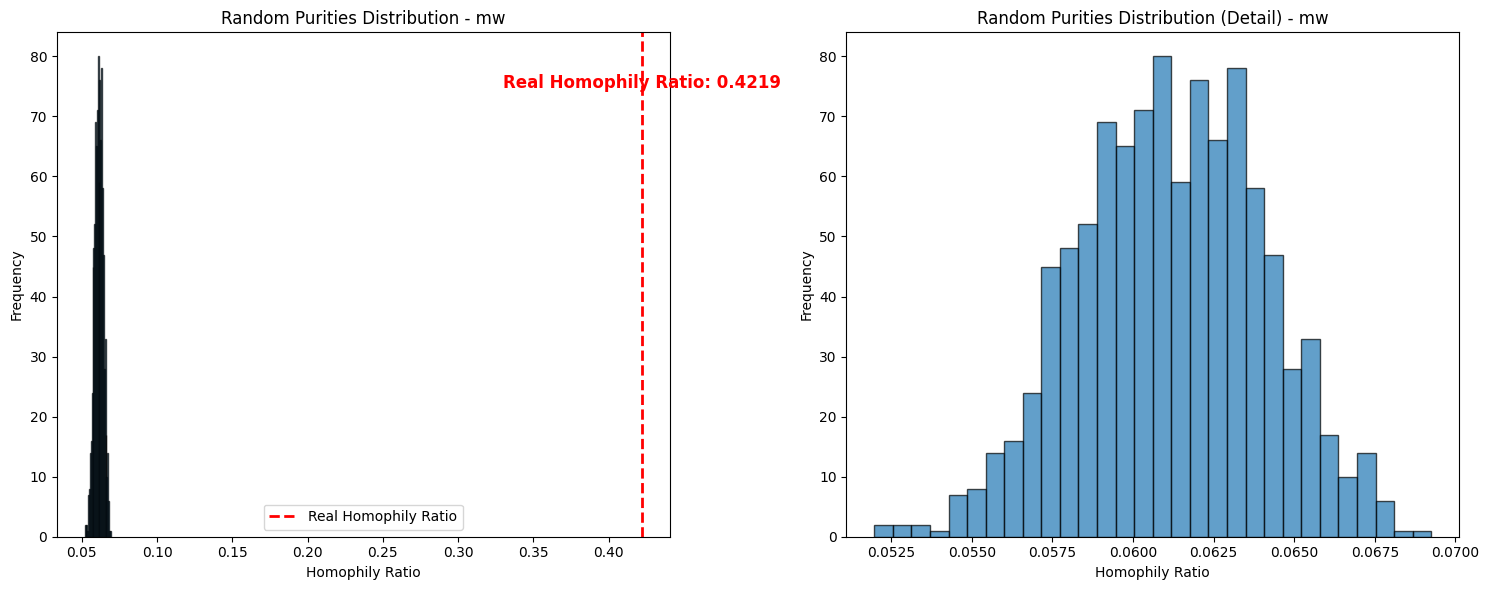

<built-in function id> 0.0 mw


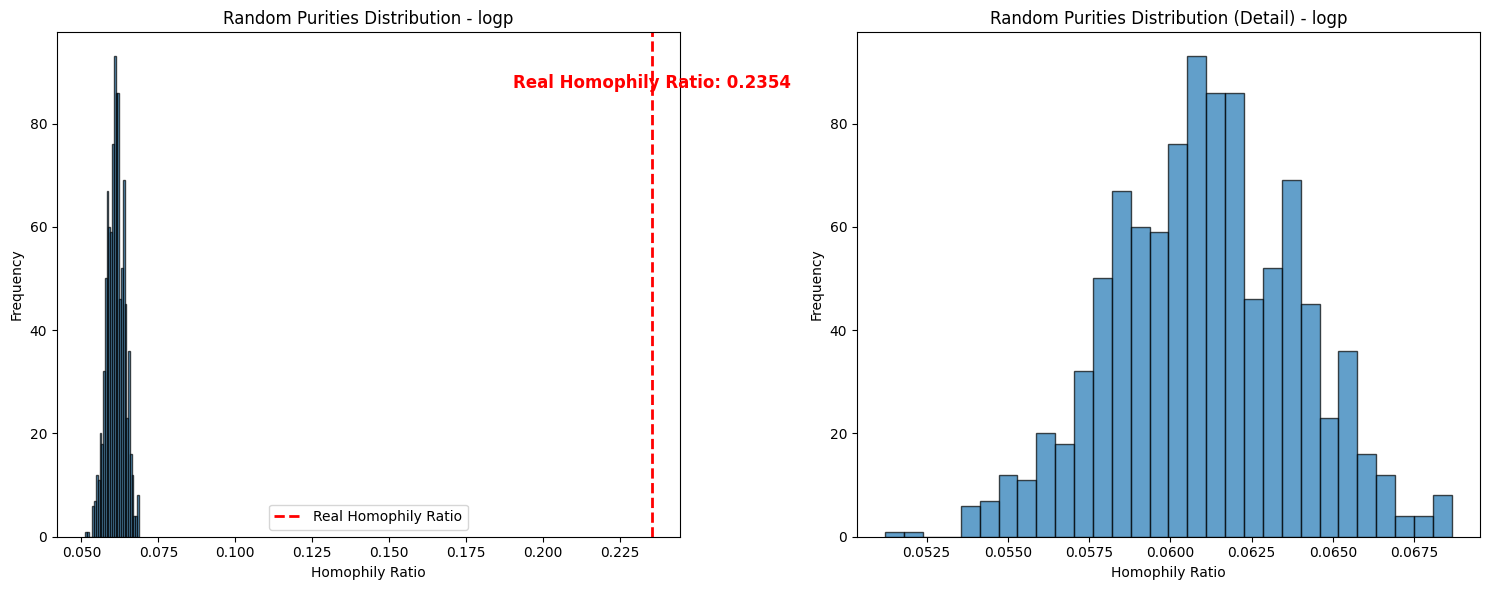

<built-in function id> 0.0 logp


In [16]:
scores = []
counter_year = collections.Counter(years)
counter_year_keys = sorted(list(counter_year.keys()))

count = []
for key in counter_year_keys:
    count.append(counter_year[key])

for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:  
    sorted_data = sorted(data)
    sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
    data_label = [0 for _ in range(len(data))]

    label = 0
    index = 0

    for i in count:
        index_next = index + i
        for j in range(index, index_next):
            data_label[sorted_data_index[j]] = label
        index = index_next
        label += 1

    labels = data_label
    labels = np.array(labels)

    lsh_purity_real = lsh_forest_purity(s, t, labels)

    random_purities = []

    for perm in range(num_permutations):
        shuffled_labels = np.random.RandomState(seed=perm).permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Purities Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Purities Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.show()

    p_value = np.mean(random_purities >= lsh_purity_real)
    print(id, p_value, label_type)

    scores.append([id, p_value, label_type])

# make tmap - all tdc's classification task

In [11]:
paths = glob.glob("../../data/processed/tdc/*/*_date.tsv")
df_details = pd.read_csv("../../data/processed/tdc/details.tsv", sep='\t', header=None)

In [12]:
tasks = {}
for i in range(len(df_details)):
    name = df_details.iloc[i, 1]
    task_type = df_details.iloc[i, 5]
    tasks[name] = task_type

classification_paths = []
for path in paths:
    task_name = os.path.basename(path).replace("_date.tsv", "")
    if tasks[task_name] != 2:
        continue
    else:
        classification_paths.append(path)

In [13]:
i = 0
output_folder_path = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/{task_name}"

df = pd.read_csv(classification_paths[i], sep='\t', header=None, names=['smiles', 'tox', 'year'])
df = df.sort_values(by='year', ascending=True).reset_index(drop=True)

smiles, years, ecfps, toxs, tpsa, mw, logp = [], [], [], [], [], [], []
for j in trange(len(df), desc="Feature Calculation"):
    smi = df.iloc[j, 0]
    mol = Chem.MolFromSmiles(smi)
    smiles.append(smi)
    years.append(int(df.iloc[j, 2]))
    ecfps.append(compute_ecfp(smi))
    toxs.append(df.iloc[j, 1])
    if mol:
        tpsa.append(Descriptors.TPSA(mol))
        mw.append(Descriptors.MolWt(mol))
        logp.append(Descriptors.MolLogP(mol))
    else:
        tpsa.append(0)
        mw.append(0)
        logp.append(0)

Feature Calculation:   0%|          | 0/5716 [00:00<?, ?it/s]

Feature Calculation: 100%|██████████| 5716/5716 [00:04<00:00, 1253.95it/s]


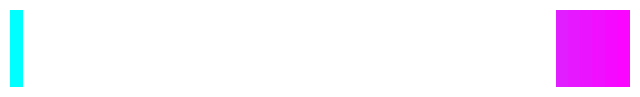

In [20]:
labels = []
for year in years:
    labels.append(year)

num_colors = min(labels)
total_colors = max(labels) - min(labels) + 1 


base_cmap = plt.get_cmap("cool")
colors = [base_cmap(i / total_colors) for i in range(total_colors)]

black_section = [(0, 0, 0, 0)] * num_colors
new_colors = black_section + colors

MY_CM = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

colors_section = new_colors[num_colors:]  

for i in range(1, len(colors_section)-6):
    colors_section[i] = (0, 0, 0, 0)

new_colors[num_colors:] = colors_section

MY_CM_SELECTED = LinearSegmentedColormap.from_list("my_map_black", colors_section, N=len(colors_section))
MY_CM_3 = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1))
plt.imshow(gradient, aspect="auto", cmap=MY_CM_SELECTED)
plt.axis("off")
plt.show()

custom_cmap = ListedColormap(
    ["#ffffff", "#ff0000"],
    name="custom",
)

custom_cmap_4 = ListedColormap(
    ["#ffffff", "#ff0000", "#00bfff", "#ffb6c1"],
    name="bright_contrast"
)

custom_cmap_6 = ListedColormap(
    ["#ffffff", "#ffff00", "#ffa500", "#ff0000", "#8b0000", "#000000"],
    name="dramatic6"
)

map_original_y = [
    [0, 'Non-Toxic (y=0)'],
    [1, 'Toxic (y=1)']
]

map_tested_y = [
    [0, 'Train (y=0)'],
    [1, 'Train (y=1)'],
    [2, 'Test - Actual Non-Toxic (y=0)'],
    [3, 'Test - Actual Toxic (y=1)']
]

map_predicted_y = [
    [0, 'Train (y=0)'],
    [1, 'Train (y=1)'],
    [2, 'Predicted Non-Toxic'],
    [3, 'Predicted Toxic']
]

map_result_labels = [
    [0, 'Train Data (y=0)'],
    [1, 'Train Data (y=1)'],
    [2, 'Correctly Predicted Non-Toxic (TN)'],
    [3, 'Correctly Predicted Toxic (TP)'],
    [4, 'Incorrectly Predicted Toxic (FP)'],  
    [5, 'Incorrectly Predicted Non-Toxic (FN)'] 
]


In [26]:
df

,smiles,tox,year
0,0,1,2.000
1,Clc1nc(Cl)nc(Nc2ccccc2Cl)n1,0,1973.025
2,c1cnc2c(c1)ccc1cccnc12,0,1973.025
3,CC(=O)Oc1ccccc1C(=O)O,0,1973.044
4,NCC1CCC(C(=O)O)CC1,0,1973.044
...,...,...,...
5711,N#Cc1c2c(c(Nc3ccc(F)cc3)n3c1nc1ccccc13)CCCC2,0,2023.819
5712,C=CCCC[PH](c1ccccc1)(c1ccccc1)c1ccccc1,0,2023.852
5713,Clc1cc2nsnc2c(Cl)n1,0,2023.877
5714,CCCCn1c2c(c3ccccc3c1=O)C(=O)c1ccccc1-2,0,2023.929


In [14]:
scores = []
num_permutations = 1000

for i in range(len(classification_paths)):
    task_name = os.path.basename(classification_paths[i]).replace('_date.tsv', '')
    output_folder_path = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/{task_name}"
    os.makedirs(output_folder_path, exist_ok=True)
    for filename in os.listdir(output_folder_path):
        file_path = os.path.join(output_folder_path, filename)
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            import shutil
            shutil.rmtree(file_path)

    df = pd.read_csv(classification_paths[i], sep='\t', header=0, names=['smiles', 'tox', 'year'])
    df = df.sort_values(by='year', ascending=True).reset_index(drop=True)

    smiles, years, ecfps, toxs, tpsa, mw, logp = [], [], [], [], [], [], []
    for j in trange(len(df), desc="Feature Calculation"):
        smi = df.iloc[j, 0]
        mol = Chem.MolFromSmiles(smi)
        smiles.append(smi)
        years.append(int(df.iloc[j, 2]))
        ecfps.append(compute_ecfp(smi))
        toxs.append(df.iloc[j, 1])
        if mol:
            tpsa.append(Descriptors.TPSA(mol))
            mw.append(Descriptors.MolWt(mol))
            logp.append(Descriptors.MolLogP(mol))
        else:
            tpsa.append(0)
            mw.append(0)
            logp.append(0)

    d, n = 2048, len(ecfps)
    enc_tm = tm.Minhash(256)
    lf_tm = tm.LSHForest(256)
    ecfp_data_tm = [tm.VectorUchar(np.array(fp)) for fp in ecfps]
    lf_tm.batch_add(enc_tm.batch_from_binary_array(ecfp_data_tm))
    lf_tm.index()
    knng_from, knng_to, knng_weight = tm.VectorUint(), tm.VectorUint(), tm.VectorFloat()
    _ = lf_tm.get_knn_graph(knng_from, knng_to, knng_weight, 10)
    x_tm, y_tm, s_tm, t_tm, _ = tm.layout_from_lsh_forest(lf_tm)

    X_ts, y_ts = ecfps, toxs
    X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(X_ts, y_ts, test_size=0.3, shuffle=False)
    le_ts = LabelEncoder()
    y_train_encoded_ts = le_ts.fit_transform(y_train_ts)
    model_ts = xgb.XGBClassifier(random_state=42)
    model_ts.fit(X_train_ts, y_train_encoded_ts)
    y_pred_ts = model_ts.predict(X_test_ts)
    predicted_y_list_ordered_ts = [None] * len(smiles)

    for i in range(len(y_train_encoded_ts)):
        predicted_y_list_ordered_ts[i] = y_train_encoded_ts[i]

    # テストデータ部分には、予測値ラベル (2 or 3) を入れる
    for i, pred_val in enumerate(y_pred_ts):
        # インデックスは訓練データの直後から始まる
        idx = len(y_train_encoded_ts) + i
        predicted_y_list_ordered_ts[idx] = 3 if pred_val >= 0.5 else 2

    result_labels_timesplit = [None] * len(smiles)
    for train_idx in range(len(y_train_encoded_ts)):
        result_labels_timesplit[train_idx] = y_train_encoded_ts[train_idx]
    for test_idx, (true_val, pred_val) in enumerate(zip(y_test_ts, y_pred_ts)):
        pred_rounded = round(pred_val)
        idx = len(y_train_ts) + test_idx
        if true_val == pred_rounded and true_val == 1: result_labels_timesplit[idx] = 3 # TP
        elif true_val == pred_rounded and true_val == 0: result_labels_timesplit[idx] = 2 # TN
        elif pred_rounded == 0: result_labels_timesplit[idx] = 5 # FN
        else: result_labels_timesplit[idx] = 4 # FP

    X_rs, y_rs = ecfps, toxs
    X_train_rs, X_test_rs, y_train_rs, y_test_rs, train_indices_rs, test_indices_rs = train_test_split(
        X_rs, y_rs, range(len(X_rs)), test_size=0.3, shuffle=True, random_state=42
    )
    le_rs = LabelEncoder()
    y_train_encoded_rs = le_rs.fit_transform(y_train_rs)
    model_rs = xgb.XGBClassifier(random_state=42)
    model_rs.fit(X_train_rs, y_train_encoded_rs)
    y_pred_rs = model_rs.predict(X_test_rs)

    predicted_y_list_ordered_rs = [None] * len(smiles)
    result_labels_ordered_rs = [None] * len(smiles)
    for i, idx in enumerate(train_indices_rs):
        predicted_y_list_ordered_rs[idx] = y_train_encoded_rs[i]
        result_labels_ordered_rs[idx] = y_train_encoded_rs[i]
    for i, idx in enumerate(test_indices_rs):
        predicted_y_list_ordered_rs[idx] = 3 if y_pred_rs[i] >= 0.5 else 2
        pred_rounded = round(y_pred_rs[i])
        if y_test_rs[i] == pred_rounded and y_test_rs[i] == 1: result_labels_ordered_rs[idx] = 3 # TP
        elif y_test_rs[i] == pred_rounded and y_test_rs[i] == 0: result_labels_ordered_rs[idx] = 2 # TN
        elif pred_rounded == 0: result_labels_ordered_rs[idx] = 5 # FN
        else: result_labels_ordered_rs[idx] = 4 # FP

    labels_year_full = [y for y in years]
    labels_year_binned = [0 if y <= 1990 else 2 if y >= 2023 else 1 for y in years]

    true_y_list_ordered_rs = y_rs
    true_y_list_ordered_ts = y_ts

    map_year_binned = {0: 'Until 1990', 1: '1991-2022', 2: 'From 2023'}
    map_toxicity = {0: 'Non-toxic', 1: 'Toxic'}
    map_predicted = {0: 'Train (Non-toxic)', 1: 'Train (Toxic)', 2: 'Pred (Non-toxic)', 3: 'Pred (Toxic)'}
    map_results = {0: 'Train (Non-toxic)', 1: 'Train (Toxic)', 2: 'True Negative', 3: 'True Positive', 4: 'False Positive', 5: 'False Negative'}

    legend_map_year_binned = [[k, v] for k, v in map_year_binned.items()]
    legend_map_toxicity = [[k, v] for k, v in map_toxicity.items()]
    legend_map_predicted = [[k, v] for k, v in map_predicted.items()]
    legend_map_results = [[k, v] for k, v in map_results.items()]
    labels_year_full_set = sorted(set(labels_year_full))
    year_label = [[y, str(y)] for y in labels_year_full_set]

    labels = []
    for year in years:
        labels.append(year)

    num_colors = min(labels)
    total_colors = max(labels) - min(labels) + 1 

    base_cmap = plt.get_cmap("cool")
    colors = [base_cmap(i / total_colors) for i in range(total_colors)]

    black_section = [(0, 0, 0, 0)] * num_colors
    new_colors = black_section + colors

    MY_CM = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

    colors_section = new_colors[num_colors:]  

    for i in range(1, len(colors_section)-6):
        colors_section[i] = (0, 0, 0, 0)

    new_colors[num_colors:] = colors_section

    MY_CM_3 = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

    gradient = np.linspace(0, 1, 256).reshape(1, -1)

    custom_cmap = ListedColormap(
        ["#ffffff", "#ff0000"],
        name="custom",
    )

    custom_cmap_4 = ListedColormap(
        ["#ffffff", "#ff0000", "#00bfff", "#ffb6c1"],
        name="bright_contrast"
    )

    custom_cmap_6 = ListedColormap(
        ["#ffffff", "#ffff00", "#ffa500", "#ff0000", "#8b0000", "#000000"],
        name="dramatic6"
    )

    legend_labels_list = [
        year_label,                   
        year_label,  
        legend_map_toxicity,        
        legend_map_toxicity,
        legend_map_toxicity,   
        legend_map_predicted,      
        legend_map_predicted,   
        legend_map_results,         
        legend_map_results           
    ]

    task_name = task_name[2:]
    faerun = Faerun(clear_color="#111111", view="front", coords=False)
    faerun.add_scatter(
        task_name,
        {"x": x_tm, "y": y_tm, "labels": smiles,
            "c": [labels_year_full, labels_year_full, toxs, true_y_list_ordered_rs, true_y_list_ordered_ts,
                predicted_y_list_ordered_rs, predicted_y_list_ordered_ts, result_labels_ordered_rs, result_labels_timesplit]},
        shader="smoothCircle",
        series_title=["Year (Full)", "Year (Binned)", "Original Y", "True Y (Random Split)",
                    "True Y (Time Split)", "Predicted Y (Random)", "Predicted Y (Time Split)", "Result (Random)", "Result (Time-based)"],
        categorical=[True, True, True, True, True, True, True, True, True],
        legend_labels=legend_labels_list,
        colormap=[MY_CM, MY_CM_3, custom_cmap, custom_cmap, custom_cmap, custom_cmap_4, custom_cmap_4, custom_cmap_6, custom_cmap_6],
        point_scale=2.5,
        max_point_size=20,
        has_legend=True,
    )
    faerun.add_tree(
        f"{task_name}_tree", {"from": s_tm, "to": t_tm}, point_helper=task_name, color="#666666"
    )

    faerun.plot(f"{output_folder_path}/tmap", template="smiles")

    for labels_data, label_type in [(np.array(labels_year_full), "year_full"), (np.array(labels_year_binned), "year_binned")]:
        purity_real = lsh_forest_purity(s_tm, t_tm, labels_data)
        random_purities = [lsh_forest_purity(s_tm, t_tm, np.random.permutation(labels_data)) for _ in range(num_permutations)]
        p_value = np.mean(np.array(random_purities) >= purity_real)
        scores.append([task_name, p_value, label_type])
        print(f"Purity for '{label_type}': Real={purity_real:.4f}, p-value={p_value:.4f}")

        plt.figure(figsize=(8, 6))
        plt.hist(random_purities, bins=30, edgecolor='black', alpha=0.7, label=f'Random Permutations (N={num_permutations})')
        plt.axvline(purity_real, color='red', linestyle='dashed', linewidth=2, label=f'Real Homophily Ratio: {purity_real:.4f}')
        plt.title(f"Homophily Ratio Distribution - {task_name} - {label_type}")
        plt.xlabel("Homophily Ratio"), plt.ylabel("Frequency"), plt.legend()
        plt.savefig(f"{output_folder_path}/random_homophily_ratios_{label_type}.png"), plt.close()

    year_counts = list(collections.Counter(sorted(years)).values())
    for prop_data, prop_name in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:
        sorted_indices = np.argsort(prop_data)
        prop_labels = np.zeros(len(prop_data), dtype=int)
        current_label, current_index = 0, 0
        for count in year_counts:
            indices_to_label = sorted_indices[current_index : current_index + count]
            prop_labels[indices_to_label] = current_label
            current_index += count
            current_label += 1
        
        purity_real = lsh_forest_purity(s_tm, t_tm, prop_labels)
        random_purities = [lsh_forest_purity(s_tm, t_tm, np.random.permutation(prop_labels)) for _ in range(num_permutations)]
        p_value = np.mean(np.array(random_purities) >= purity_real)
        scores.append([task_name, p_value, prop_name])
        print(f"Homophily Ratio for '{prop_name}': Real={purity_real:.4f}, p-value={p_value:.4f}")

        plt.figure(figsize=(8, 6))
        plt.hist(random_purities, bins=30, edgecolor='black', alpha=0.7, label=f'Random Permutations (N={num_permutations})')
        plt.axvline(purity_real, color='red', linestyle='dashed', linewidth=2, label=f'Real Homophily Ratio: {purity_real:.4f}')
        plt.title(f"Homophily Ratio Distribution - {task_name} - {prop_name}"), plt.xlabel("Homophily Ratio"), plt.ylabel("Frequency"), plt.legend()
        plt.savefig(f"{output_folder_path}/random_homophily_ratios_{prop_name}.png"), plt.close()

    filepaths = {"x": f"{output_folder_path}/x.pkl", "y": f"{output_folder_path}/y.pkl",
                "s": f"{output_folder_path}/s.pkl", "t": f"{output_folder_path}/t.pkl"}
    pickle_dump(list(x_tm), filepaths["x"])
    pickle_dump(list(y_tm), filepaths["y"])
    pickle_dump(list(s_tm), filepaths["s"])
    pickle_dump(list(t_tm), filepaths["t"])

Feature Calculation: 100%|██████████| 5715/5715 [00:04<00:00, 1186.27it/s]


/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/3_HIV/tmap.html

Purity for 'year_full': Real=0.1271, p-value=0.0000
Purity for 'year_binned': Real=0.5940, p-value=0.0000
Homophily Ratio for 'tpsa': Real=0.2387, p-value=0.0000
Homophily Ratio for 'mw': Real=0.1120, p-value=0.0000
Homophily Ratio for 'logp': Real=0.1250, p-value=0.0000


Feature Calculation: 100%|██████████| 15924/15924 [00:12<00:00, 1282.16it/s]


/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_orexin1_receptor_butkiewicz/tmap.html

...

/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/6_DILI/tmap.html

Purity for 'year_full': Real=0.1901, p-value=0.0000
Purity for 'year_binned': Real=0.8099, p-value=0.0000
Homophily Ratio for 'tpsa': Real=0.2793, p-value=0.0000
Homophily Ratio for 'mw': Real=0.1831, p-value=0.0000
Homophily Ratio for 'logp': Real=0.2277, p-value=0.0000


Feature Calculation: 100%|██████████| 205/205 [00:00<00:00, 1048.78it/s]


/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/8_Carcinogens_Lagunin/tmap.html

Purity for 'year_full': Real=0.1422, p-value=0.0180
Purity for 'year_binned': Real=0.6765, p-value=0.0860
Homophily Ratio for 'tpsa': Real=0.2157, p-value=0.0000
Homophily Ratio for 'mw': Real=0.2010, p-value=0.0000
Homophily Ratio for 'logp': Real=0.2157, p-value=0.0000


In [15]:
pd.DataFrame(scores, columns=["ID", "P-value", "Label Type"]).to_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/scores.csv", index=False)

# make tmap for toxcast

In [20]:
df = pd.read_csv("../../data/processed/moleculenet/moleculenet_patentdate/toxcast/date_dataset.tsv", sep="\t", header=None)

In [21]:
smiles = []
years = []
ecfps = []
toxs = []
tpsa = []
mw = []
logp = []

for i in trange(len(df)):
    smiles.append(df.iloc[i,0])
    years.append(int(df.iloc[i,1]))
    ecfps.append(compute_ecfp(df.iloc[i,0]))
    mol = Chem.MolFromSmiles(df.iloc[i,0])
    tpsa.append(Descriptors.MolWt(mol))
    mw.append(Descriptors.TPSA(mol))
    logp.append(Descriptors.MolLogP(mol))

  0%|          | 0/6857 [00:00<?, ?it/s]

100%|██████████| 6857/6857 [00:05<00:00, 1188.53it/s]


In [22]:
enc = tm.Minhash(128)
lf = tm.LSHForest(128)

d = 2048
n = len(smiles)

data = []
start = timer()
for x in trange(n):
    data.append(tm.VectorUchar(np.array(ecfps[x])))
print(f"Generating the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.batch_add(enc.batch_from_binary_array(data))
print(f"Adding the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.index()
print(f"Indexing took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
knng_from = tm.VectorUint()
knng_to = tm.VectorUint()
knng_weight = tm.VectorFloat()

_ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)
print(f"make knn graph {(timer() - start) * 1000}ms.", flush=True)

  0%|          | 0/6857 [00:00<?, ?it/s]

100%|██████████| 6857/6857 [00:13<00:00, 519.75it/s]

Generating the data took 13195.399010553956ms.
Adding the data took 6750.750042498112ms.


Indexing took 995.1974134892225ms.
make knn graph 3406.32220543921ms.


In [23]:
labels = []
for year in years:
    labels.append(year)

In [24]:
x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

faerun = Faerun(clear_color="#111111", view="front", coords=False)

faerun.add_scatter(
    "tdc_12_hERG",
    {"x": x, "y": y, "c": [labels, labels], "labels": smiles},
    colormap=[MY_CM, MY_CM_3],
    shader="smoothCircle",
    series_title=["Year", "Year_2"], 
    categorical=[True, True],
    point_scale=2.5,
    max_point_size=30,
    has_legend=True,
)
faerun.add_tree(
    "tdc_12_hERG_tree", {"from": s, "to": t}, point_helper="tdc_12_hERG", color="#666666"
)

faerun.plot("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/toxcast/tmap", template="smiles")

/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/toxcast/tmap.html

In [25]:
output_folder_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/toxcast"

filepaths = {
    "x": f"{output_folder_path}/x.pkl",
    "y": f"{output_folder_path}/y.pkl",
    "s": f"{output_folder_path}/s.pkl",
    "t": f"{output_folder_path}/t.pkl",
}

pickle_dump(list(x), filepaths["x"])
pickle_dump(list(y), filepaths["y"])
pickle_dump(list(s), filepaths["s"])
pickle_dump(list(t), filepaths["t"])

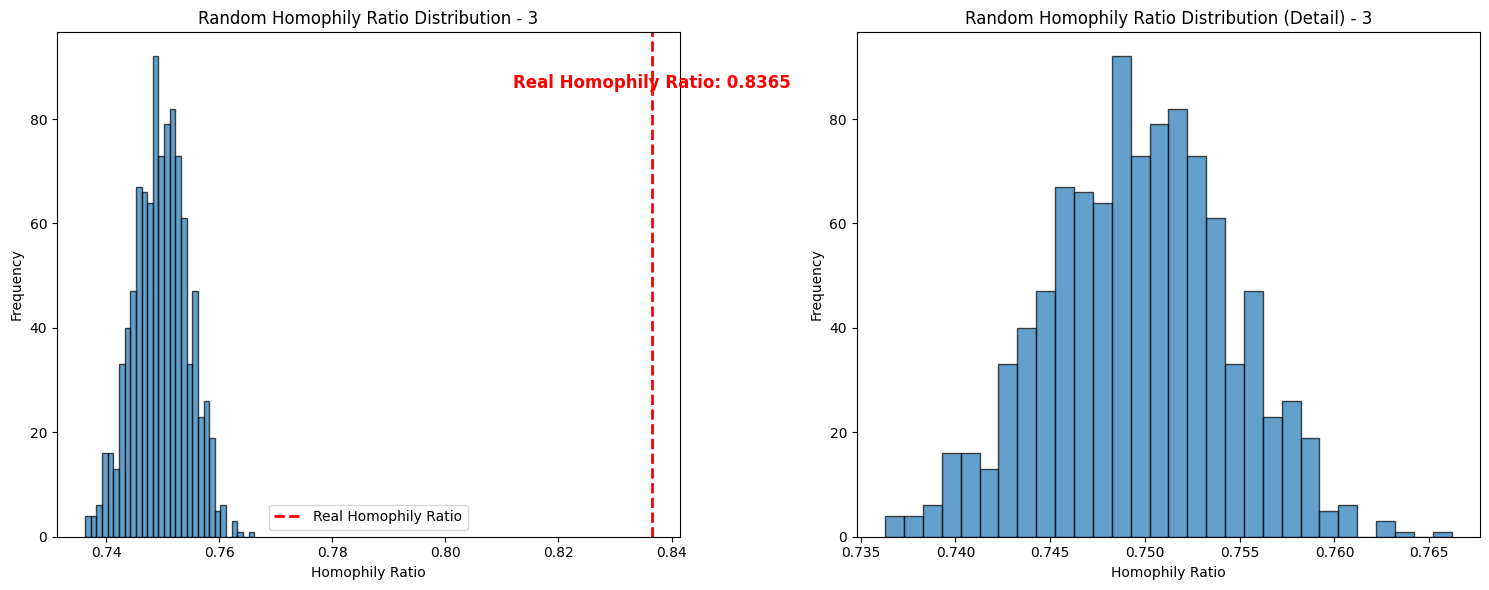

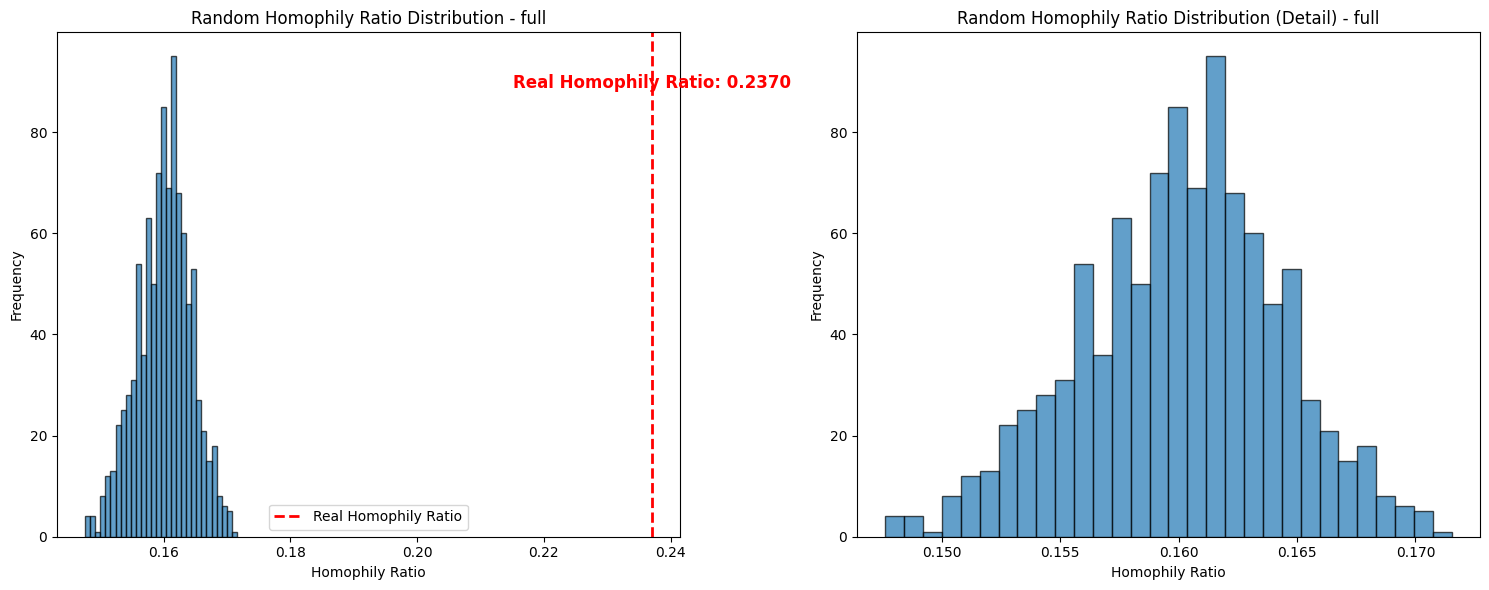

In [26]:
labels_full = [year for year in years]
labels_3 = [0 if year <= 1990 else 2 if year >= 2023 else 1 for year in years]
labels_3, labels_full = np.array(labels_3), np.array(labels_full)

scores = []
scores.append([id, lsh_forest_purity(s, t, labels_3), "3"])
scores.append([id, lsh_forest_purity(s, t, labels_full), "full"])

for labels, label_type in [(labels_3, "3"), (labels_full, "full")]:
    lsh_purity_real = lsh_forest_purity(s, t, labels)
    random_purities = []
    for _ in range(num_permutations):
        shuffled_labels = np.random.permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 
    
    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Homophily Ratio Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Homophily Ratio Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_folder_path}/random_purities_{label_type}.png")

    scores.append([id, p_value, label_type])

hist_3_path = os.path.join(output_folder_path, "hist_3.png")
hist_full_path = os.path.join(output_folder_path, "hist_full.png")

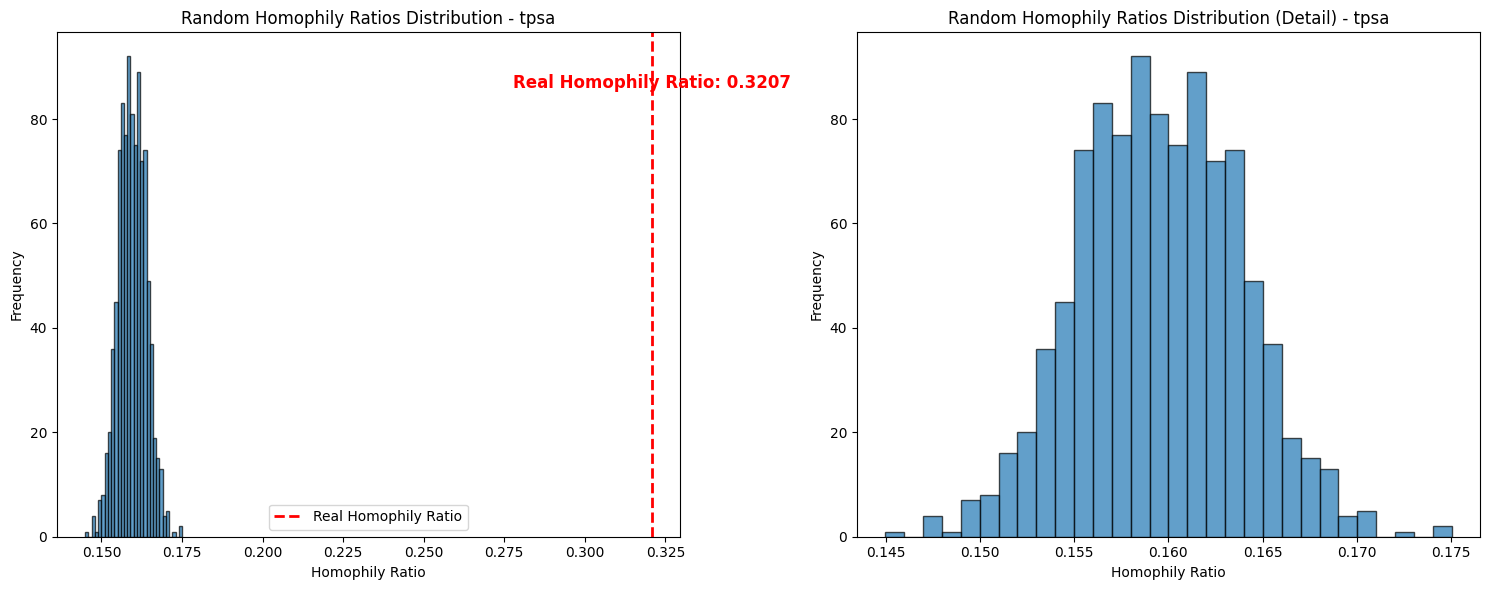

<built-in function id> 0.0 tpsa


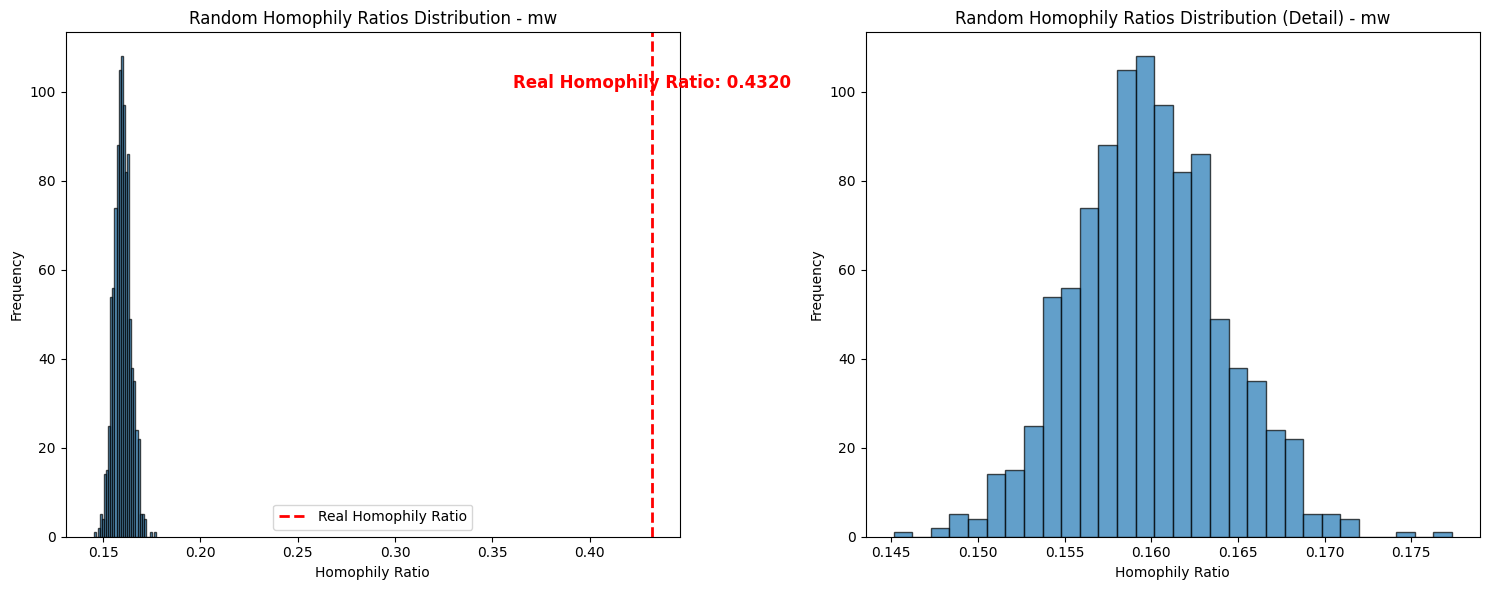

<built-in function id> 0.0 mw


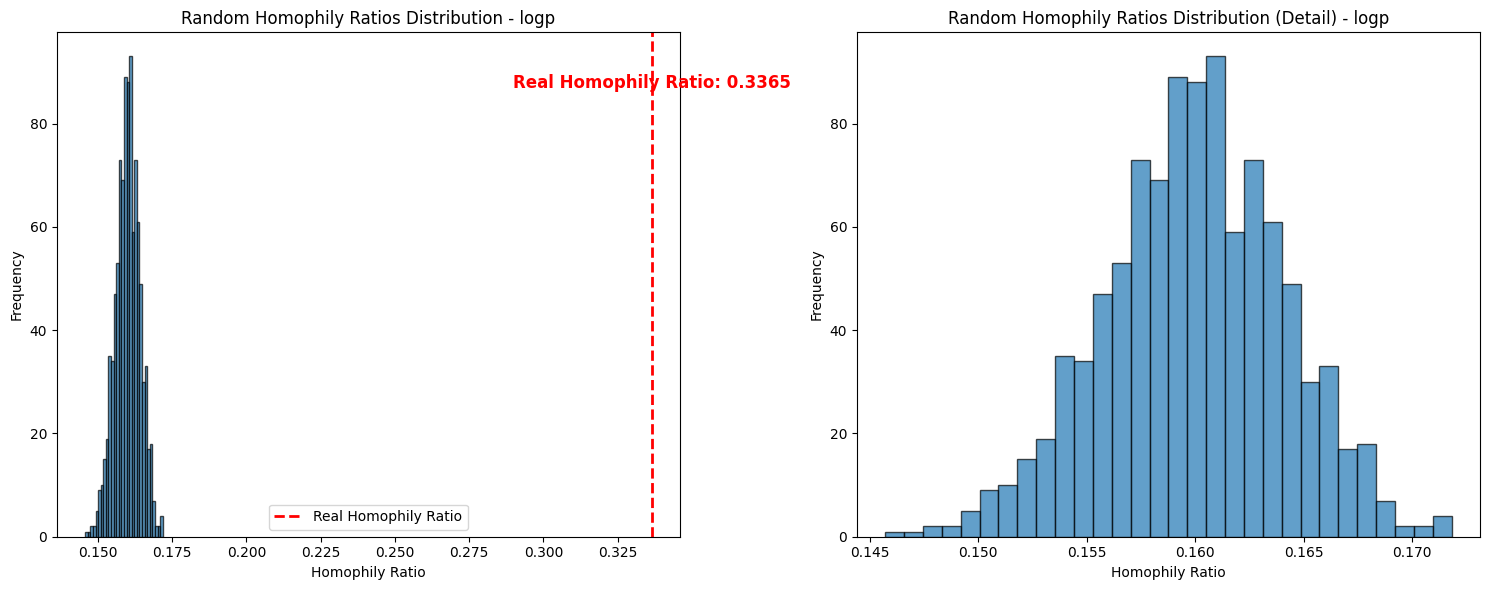

<built-in function id> 0.0 logp


In [27]:
counter_year = collections.Counter(years)
counter_year_keys = sorted(list(counter_year.keys()))

count = []
for key in counter_year_keys:
    count.append(counter_year[key])

for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:  
    sorted_data = sorted(data)
    sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
    data_label = [0 for _ in range(len(data))]

    label = 0
    index = 0

    for i in count:
        index_next = index + i
        for j in range(index, index_next):
            data_label[sorted_data_index[j]] = label
        index = index_next
        label += 1

    labels = data_label
    labels = np.array(labels)

    lsh_purity_real = lsh_forest_purity(s, t, labels)

    random_purities = []

    for perm in range(num_permutations):
        shuffled_labels = np.random.RandomState(seed=perm).permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Homophily Ratios Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Homophily Ratios Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_folder_path}/random_homophily_ratios_{label_type}.png")
    plt.show()

    p_value = np.mean(random_purities >= lsh_purity_real)
    print(id, p_value, label_type)

    scores.append([id, p_value, label_type])

In [28]:
pd.DataFrame(scores).to_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/toxcast/scores.csv", index=False)

# tmap for tox21

In [29]:
df = pd.read_csv("../../data/processed/moleculenet/moleculenet_patentdate/tox21/date_dataset.tsv", sep="\t", header=None)

In [30]:
smiles = []
years = []
ecfps = []
toxs = []
tpsa = []
mw = []
logp = []

for i in trange(len(df)):
    smiles.append(df.iloc[i,0])
    years.append(int(df.iloc[i,1]))
    ecfps.append(compute_ecfp(df.iloc[i,0]))
    mol = Chem.MolFromSmiles(df.iloc[i,0])
    tpsa.append(Descriptors.MolWt(mol))
    mw.append(Descriptors.TPSA(mol))
    logp.append(Descriptors.MolLogP(mol))

  0%|          | 0/6178 [00:00<?, ?it/s]

100%|██████████| 6178/6178 [00:04<00:00, 1311.29it/s]


In [31]:
enc = tm.Minhash(128)
lf = tm.LSHForest(128)

d = 2048
n = len(smiles)

data = []
start = timer()
for x in trange(n):
    data.append(tm.VectorUchar(np.array(ecfps[x])))
print(f"Generating the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.batch_add(enc.batch_from_binary_array(data))
print(f"Adding the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.index()
print(f"Indexing took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
knng_from = tm.VectorUint()
knng_to = tm.VectorUint()
knng_weight = tm.VectorFloat()

_ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)
print(f"make knn graph {(timer() - start) * 1000}ms.", flush=True)

100%|██████████| 6178/6178 [00:11<00:00, 554.90it/s]

Generating the data took 11135.438714176416ms.


Adding the data took 5143.882382661104ms.
Indexing took 700.1081462949514ms.
make knn graph 3100.2930011600256ms.


In [32]:
labels = []
for year in years:
    labels.append(year)

In [33]:
x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

faerun = Faerun(clear_color="#111111", view="front", coords=False)

faerun.add_scatter(
    "tdc_12_hERG",
    {"x": x, "y": y, "c": [labels, labels], "labels": smiles},
    colormap=[MY_CM, MY_CM_3],
    shader="smoothCircle",
    series_title=["Year", "Year_2"], 
    categorical=[True, True],
    point_scale=2.5,
    max_point_size=30,
    has_legend=True,
)
faerun.add_tree(
    "tdc_12_hERG_tree", {"from": s, "to": t}, point_helper="tdc_12_hERG", color="#666666"
)

faerun.plot("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/tox21/tmap", template="smiles")

/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/tox21/tmap.html

In [34]:
output_folder_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/tox21"

filepaths = {
    "x": f"{output_folder_path}/x.pkl",
    "y": f"{output_folder_path}/y.pkl",
    "s": f"{output_folder_path}/s.pkl",
    "t": f"{output_folder_path}/t.pkl",
}

pickle_dump(list(x), filepaths["x"])
pickle_dump(list(y), filepaths["y"])
pickle_dump(list(s), filepaths["s"])
pickle_dump(list(t), filepaths["t"])

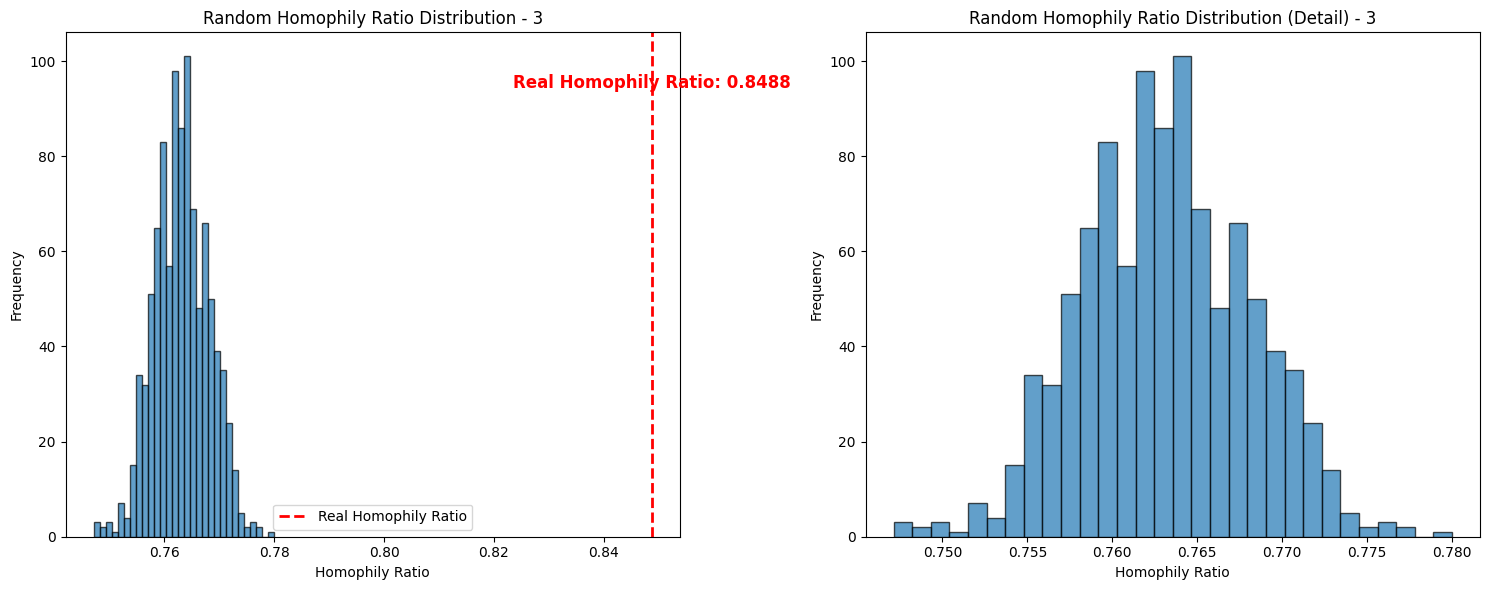

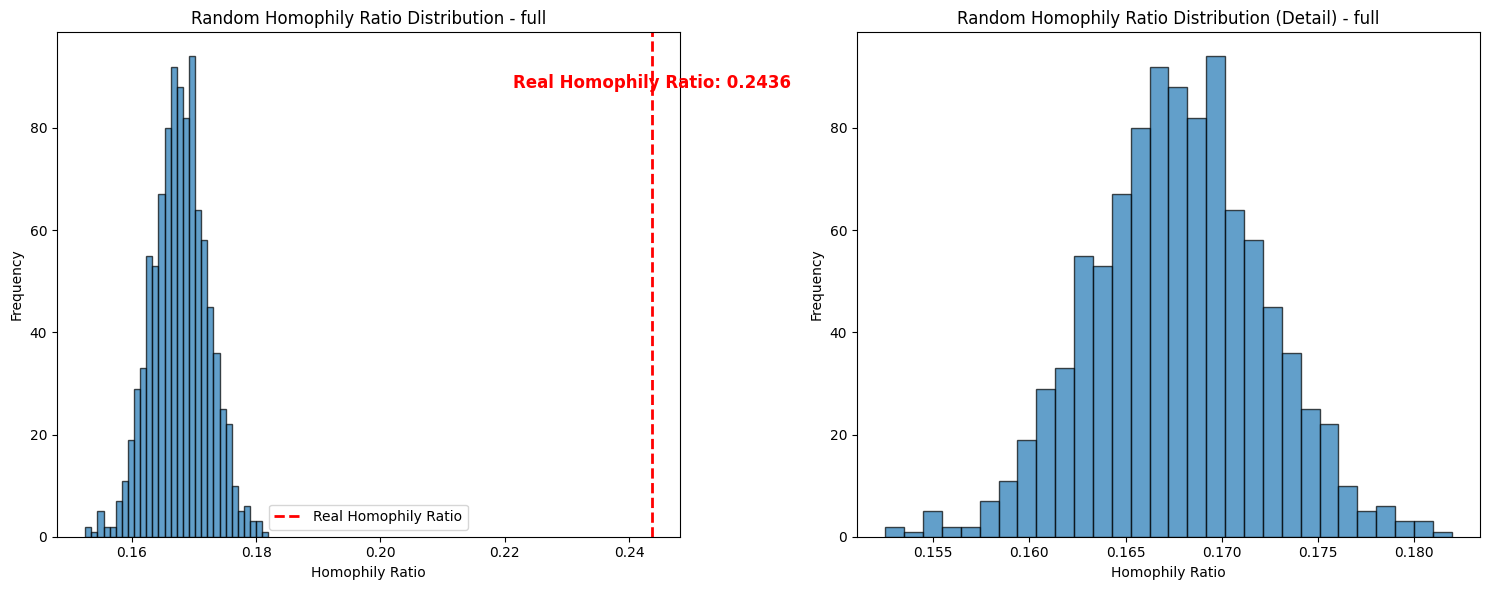

In [35]:
labels_full = [year for year in years]
labels_3 = [0 if year <= 1990 else 2 if year >= 2023 else 1 for year in years]
labels_3, labels_full = np.array(labels_3), np.array(labels_full)

scores = []
scores.append([id, lsh_forest_purity(s, t, labels_3), "3"])
scores.append([id, lsh_forest_purity(s, t, labels_full), "full"])

for labels, label_type in [(labels_3, "3"), (labels_full, "full")]:
    lsh_purity_real = lsh_forest_purity(s, t, labels)
    random_purities = []
    for _ in range(num_permutations):
        shuffled_labels = np.random.permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 
    
    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Homophily Ratio Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Homophily Ratio Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_folder_path}/random_homophily_ratios_{label_type}.png")

    scores.append([id, p_value, label_type])

hist_3_path = os.path.join(output_folder_path, "hist_3.png")
hist_full_path = os.path.join(output_folder_path, "hist_full.png")

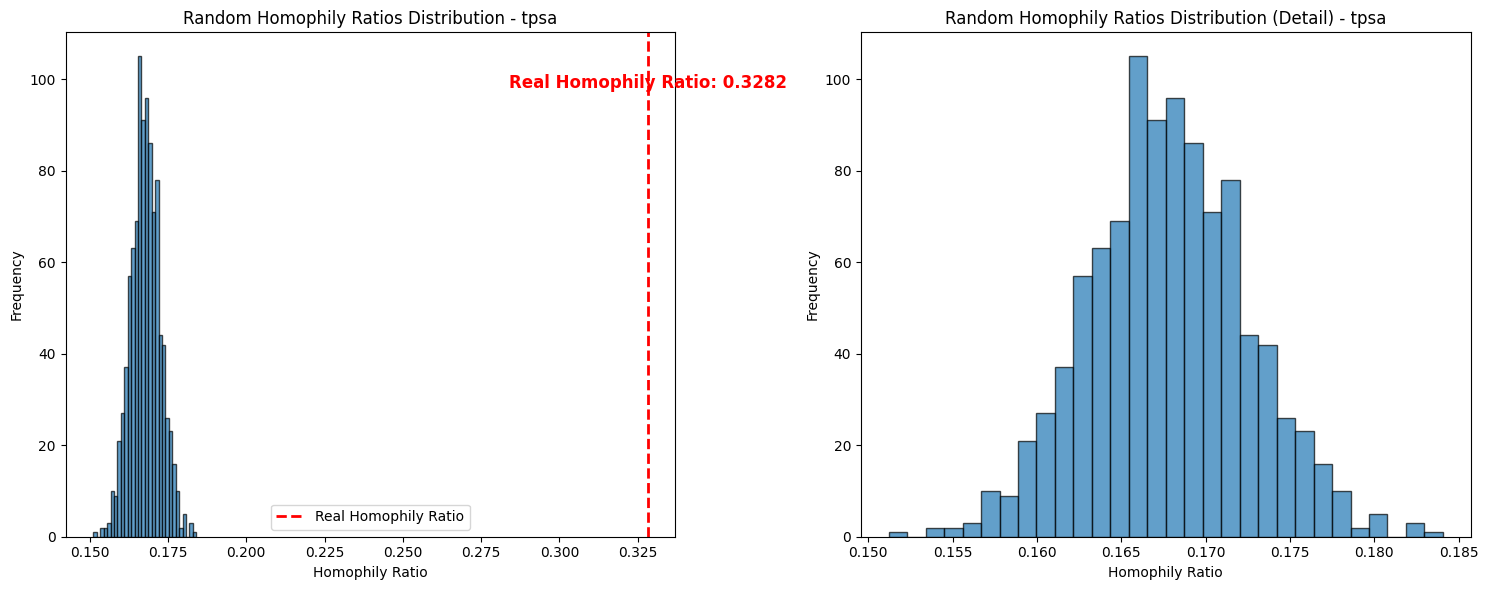

<built-in function id> 0.0 tpsa


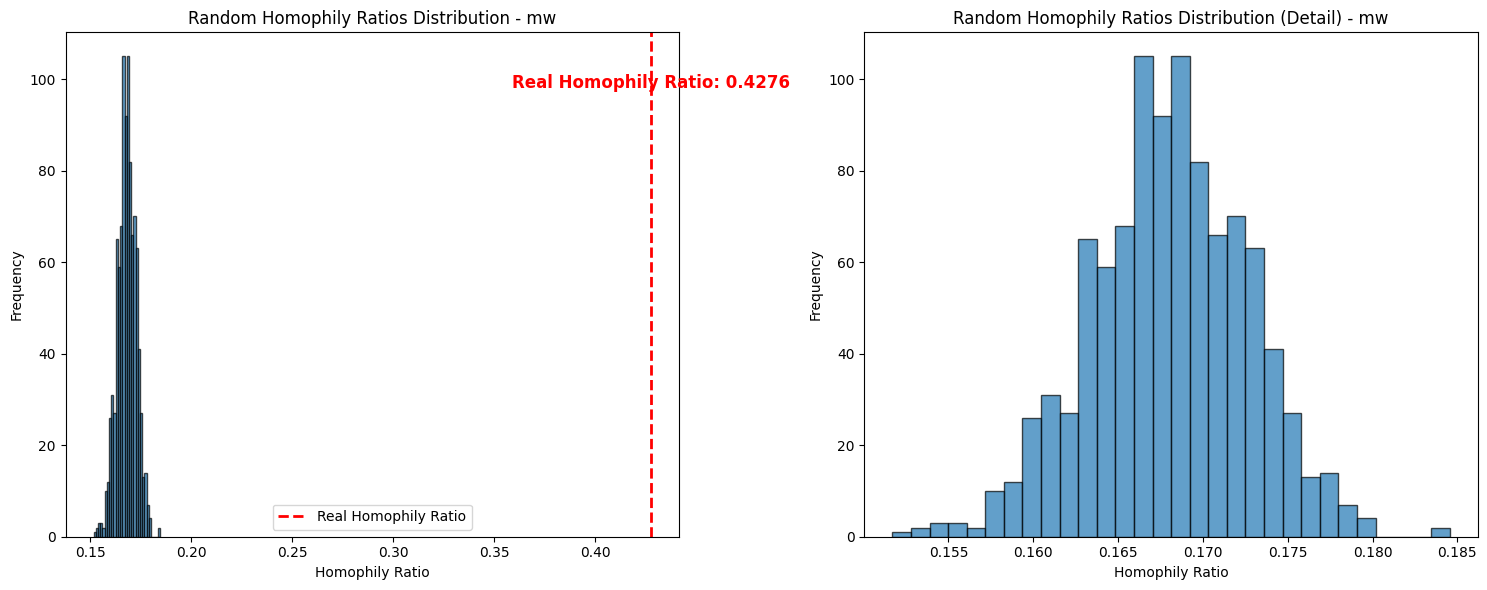

<built-in function id> 0.0 mw


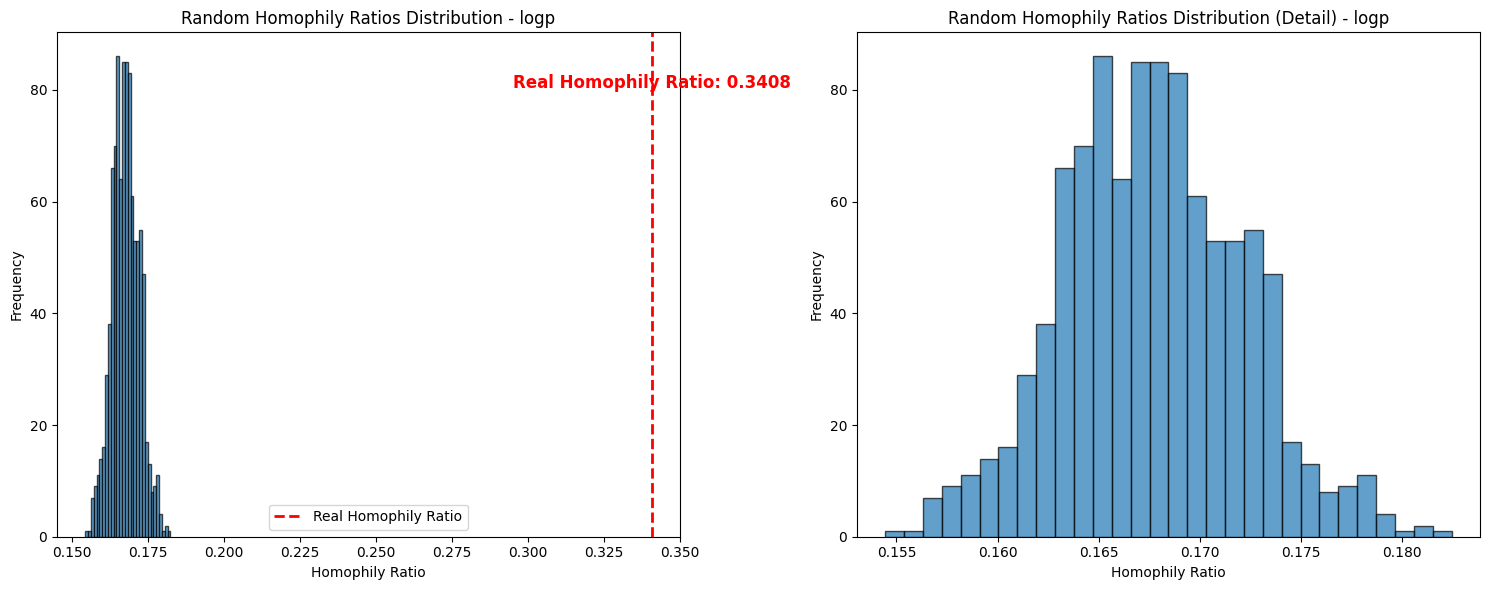

<built-in function id> 0.0 logp


In [36]:
counter_year = collections.Counter(years)
counter_year_keys = sorted(list(counter_year.keys()))

count = []
for key in counter_year_keys:
    count.append(counter_year[key])

for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:  
    sorted_data = sorted(data)
    sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
    data_label = [0 for _ in range(len(data))]

    label = 0
    index = 0

    for i in count:
        index_next = index + i
        for j in range(index, index_next):
            data_label[sorted_data_index[j]] = label
        index = index_next
        label += 1

    labels = data_label
    labels = np.array(labels)

    lsh_purity_real = lsh_forest_purity(s, t, labels)

    random_purities = []

    for perm in range(num_permutations):
        shuffled_labels = np.random.RandomState(seed=perm).permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Homophily Ratios Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Homophily Ratios Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_folder_path}/random_homophily_ratios_{label_type}.png")
    plt.show()

    p_value = np.mean(random_purities >= lsh_purity_real)
    print(id, p_value, label_type)

    scores.append([id, p_value, label_type])

In [37]:
pd.DataFrame(scores).to_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/tox21/scores.csv", index=False)

# homophily ratio analysis

In [38]:
homophily_labels = []
for i in range(len(classification_paths)):
    id = i
    tdc_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc"
    output_folder_path = f"{tdc_path}/{os.path.basename(classification_paths[i]).replace('_date.tsv', '')}"
    path = classification_paths[i]

    s_path = os.path.join(output_folder_path, "s.pkl")
    t_path = os.path.join(output_folder_path, "t.pkl")
    
    s = pickle_load(s_path)
    t = pickle_load(t_path)
    df = pd.read_csv(path, sep='\t')
    
    smiles = []
    years = []
    ecfps = []
    toxs = []
    tpsa = []
    mw = []
    logp = []

    for j in trange(len(df)):
        smiles.append(df.iloc[j, 0])
        years.append(int(df.iloc[j, 2]))
        ecfps.append(compute_ecfp(df.iloc[j, 0]))
        toxs.append(df.iloc[j, 1])
        mol = Chem.MolFromSmiles(df.iloc[j, 0])
        tpsa.append(Descriptors.MolWt(mol))
        mw.append(Descriptors.TPSA(mol))
        logp.append(Descriptors.MolLogP(mol))
    
    labels_full = [year for year in years]
    labels_full = np.array(labels_full)
    lsh_purity_real = lsh_forest_purity(s, t, labels_full)
    homophily_labels.append([i, lsh_purity_real, "year"])

    counter_year = collections.Counter(years)
    counter_year_keys = sorted(list(counter_year.keys()))

    count = []
    for key in counter_year_keys:
        count.append(counter_year[key])

    for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:
        sorted_data = sorted(data)
        sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
        data_label = [0 for _ in range(len(data))]

        label = 0
        index = 0

        for i in count:
            index_next = index + i
            for j in range(index, index_next):
                data_label[sorted_data_index[j]] = label
            index = index_next
            label += 1

        labels = data_label
        labels = np.array(labels)

        lsh_purity_real = lsh_forest_purity(s, t, labels)
        homophily_labels.append([id, lsh_purity_real, label_type])

100%|██████████| 205/205 [00:00<00:00, 1367.69it/s]


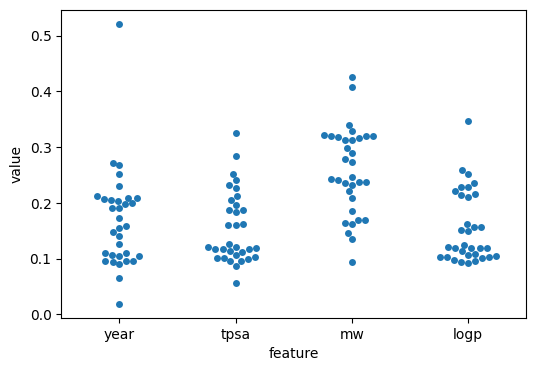

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.DataFrame(homophily_labels, columns=["id", "value", "feature"])
# swarmplot
plt.figure(figsize=(6, 4))
sns.swarmplot(x="feature", y="value", data=df)
plt.savefig("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/homophily_labels.png", dpi=300)

# search compound in network

In [4]:
import pandas as pd
df = pd.read_csv("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/processed/tdc/Tox/4_hERG_Karim_date.tsv", sep="\t", header=0, names=["smiles", "tox", "year"])
df = df.sort_values(by="year").reset_index(drop=True)

import pickle
s = pickle.load(open("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_hERG_Karim/s.pkl", "rb"))
t = pickle.load(open("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_hERG_Karim/t.pkl", "rb"))
x = pickle.load(open("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_hERG_Karim/x.pkl", "rb"))
y = pickle.load(open("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_hERG_Karim/y.pkl", "rb"))

In [5]:
smiles = 'Cc1ncc(OC[C@@]2(c3cccc(F)c3)C[C@H]2C(=O)Nc2cc(C)c(F)cn2)c(C)n1'
for i in range(len(df)):
    if df.iloc[i,0] == smiles:
        matched_index = i
        print(i)
        print(df.iloc[i])
        break

5284
smiles    Cc1ncc(OC[C@@]2(c3cccc(F)c3)C[C@H]2C(=O)Nc2cc(...
tox                                                       0
year                                               2012.301
Name: 5284, dtype: object


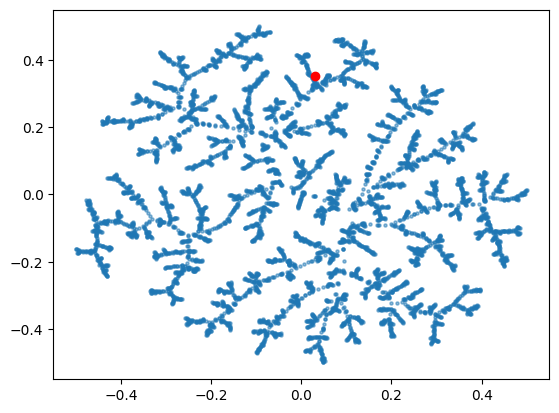

In [16]:
from matplotlib import pyplot as plt
plt.scatter(x, y, alpha=0.5, s=5)
plt.scatter(x[matched_index], y[matched_index], color='red')